# Task 4 - CNN MNIST model and Adversarial Images

In this notebook, we trained a CNN MNIST model and created adversarial images to classify 4s as 9s. Reasoned how these adversarial images are produced. And a random noise image was used to classify it as nine and observed the results. Compare the results from the first and the second steps.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# --- CNN Architecture ---
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [ ]:
# --- Train the Model ---
def train_model():
    model = MNIST_CNN().to(device)
    transform = transforms.ToTensor()
    train_loader = torch.utils.data.DataLoader(
        datasets.MNIST("./MNIST", train=True, download=True, transform=transform),
        batch_size=64,
        shuffle=True,
    )
    val_loader = torch.utils.data.DataLoader(
        datasets.MNIST("./MNIST", train=False, download=True, transform=transform),
        batch_size=64,
        shuffle=False,
    )

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_loss_history = []
    val_loss_history = []

    print("Training CNN Classifier...")
    for epoch in range(1, 6):
        model.train()
        epoch_loss = 0.0
        for data, target in tqdm(train_loader, desc=f"Epoch {epoch}"):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_train_loss = epoch_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_loss_history.append(avg_val_loss)
        print(
            f"Epoch {epoch} - train_loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}"
        )

    print("Training Complete.\n")

    plt.figure(figsize=(6, 4))
    plt.plot(train_loss_history, marker="o", label="Train")
    plt.plot(val_loss_history, marker="o", label="Val")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("CrossEntropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return model

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.39MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 268kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.4MB/s]


Training CNN Classifier...


Epoch 1: 100%|██████████| 938/938 [00:10<00:00, 93.48it/s] 


Epoch 1 - train_loss: 0.1546 - val_loss: 0.0452


Epoch 2: 100%|██████████| 938/938 [00:09<00:00, 96.35it/s] 


...

Epoch 3 - train_loss: 0.0297 - val_loss: 0.0372


Epoch 4: 100%|██████████| 938/938 [00:09<00:00, 96.67it/s] 


Epoch 4 - train_loss: 0.0219 - val_loss: 0.0306


Epoch 5: 100%|██████████| 938/938 [00:10<00:00, 92.85it/s] 


Epoch 5 - train_loss: 0.0166 - val_loss: 0.0336
Training Complete.



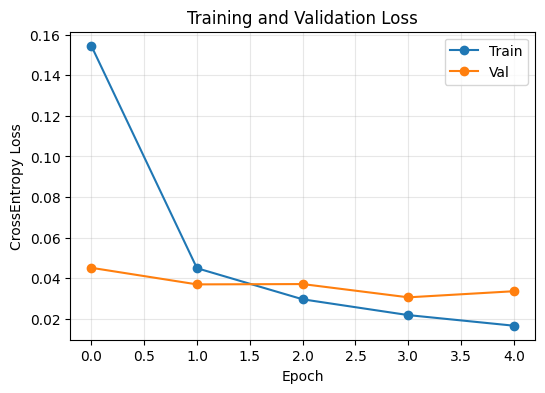

In [4]:
# Training CNN Model
classifier = train_model()

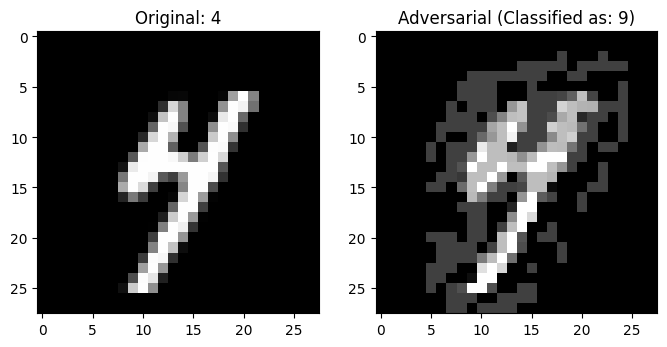

In [ ]:
#  Targeted Adversarial Attack: 4 as 9
def run_adversarial_attack(model, epsilon=0.25):
    model.eval()
    # Loading MNIST test set to find a '4'
    test_loader = torch.utils.data.DataLoader(
        datasets.MNIST("./MNIST", train=False, transform=transforms.ToTensor()),
        batch_size=1,
        shuffle=True,
    )

    for data, target in test_loader:
        if target.item() == 4:
            data, target = data.to(device), target.to(device)
            data.requires_grad = True
            # Forward pass
            output = model(data)
            # Targeted Loss: We want the model to think this is a '9'
            target_fake = torch.tensor([9]).to(device)
            loss = F.cross_entropy(output, target_fake)
            # Backward pass to get gradients w.r.t the IMAGE pixels
            model.zero_grad()
            loss.backward()
            # FGSM: Move pixels in the direction that minimizes loss for '9'
            # We subtract the gradient sign for a targeted attack
            data_grad = data.grad.data
            perturbed_image = data - epsilon * data_grad.sign()
            perturbed_image = torch.clamp(perturbed_image, 0, 1)

            # Check the new prediction
            new_output = model(perturbed_image)
            new_pred = new_output.max(1, keepdim=True)[1].item()

            # Display results if the attack was successful
            if new_pred == 9:
                plt.figure(figsize=(8, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(data.squeeze().detach().cpu().numpy(), cmap="gray")
                plt.title(f"Original: {target.item()}")
                plt.subplot(1, 2, 2)
                plt.imshow(
                    perturbed_image.squeeze().detach().cpu().numpy(), cmap="gray"
                )
                plt.title(f"Adversarial (Classified as: {new_pred})")
                plt.show()
                break


run_adversarial_attack(classifier)


## How are these adversarial images produced?

Adversarial images are created by utilizing the gradients of the trained CNN model. In normal training, we use gradients to update weights to minimize loss. In this attack (specifically the Fast Gradient Sign Method or FGSM), we keep the weights frozen and update the pixels of the input image instead.

By calculating the gradient of the loss with respect to the input image, we determine the direction in which each pixel should be changed to make the model more likely to predict a "9" instead of a "4." Even though the changes (the gray noise) look random to us, they are mathematically calculated to trigger the specific neural pathways the model associates with the number 9.

In [6]:
# Random Noise to 9
def run_noise_task(model):
    model.eval()
    # Start with pure random noise
    noise_img = torch.randn((1, 1, 28, 28), device=device) * 0.1
    noise_img = torch.clamp(noise_img, 0, 1)
    noise_img.requires_grad = True

    optimizer = optim.Adam([noise_img], lr=0.01)
    target_9 = torch.tensor([9]).to(device)

    for i in range(500):
        optimizer.zero_grad()
        output = model(noise_img)
        loss = F.cross_entropy(output, target_9)
        loss.backward()
        optimizer.step()
        noise_img.data.clamp_(0, 1)

        if output.max(1)[1].item() == 9:
            break

    final_pred = model(noise_img).max(1)[1].item()
    plt.imshow(noise_img.squeeze().detach().cpu().numpy(), cmap="gray")
    plt.title(f"Noise Hallucination (Classified as: {final_pred})")
    plt.show()

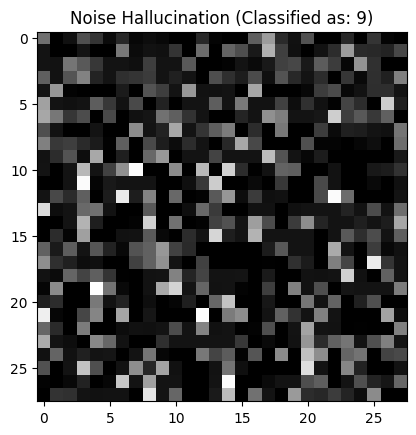

In [7]:
# Run Noise task
run_noise_task(classifier)

## Comparison of Adversarial Attack vs. Noise Hallucination

The primary difference between the two steps lies in the starting point and the intent of the optimization. In the first step (Adversarial '4'), we began with a structured, human-recognizable digit and applied a targeted perturbation. This proves that the model's decision-making is fragile, as tiny, invisible changes to a real object can completely overwrite its perceived identity.

In the second step (Noise Hallucination), we began with total chaos—random Gaussian noise—and optimized it until the model saw a '9'. This proves that the model is over-confident; it does not require the actual structural components of a number (like loops or lines) to reach a high-certainty conclusion.

Conclusion: Comparing the two steps reveals that CNNs do not learn the concept of a digit the way humans do. While we see a "4" and "static", the model sees mathematical pixel correlations. The first step shows how easily these correlations can be disrupted, and the second step shows how easily they can be fabricated from nothing.